
--- Scratch SVM ---
Train Accuracy: 0.8785714285714286
Test Accuracy: 0.8166666666666667
Training Time: 2.8251335620880127

--- Library SVM (Linear) ---
Train Accuracy: 0.8785714285714286
Test Accuracy: 0.8
Training Time: 0.011070728302001953

--- Library SVM (RBF) ---
Train Accuracy: 0.9071428571428571
Test Accuracy: 0.85
Training Time: 0.0029883384704589844


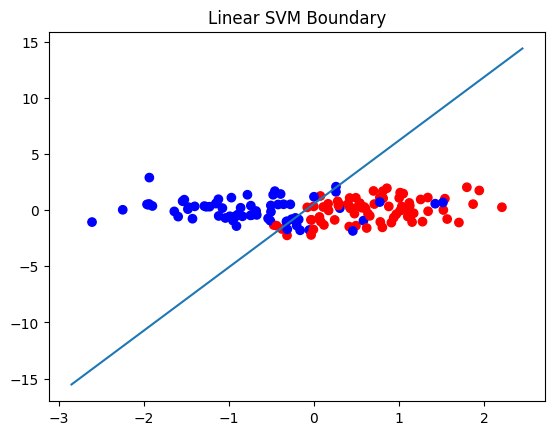

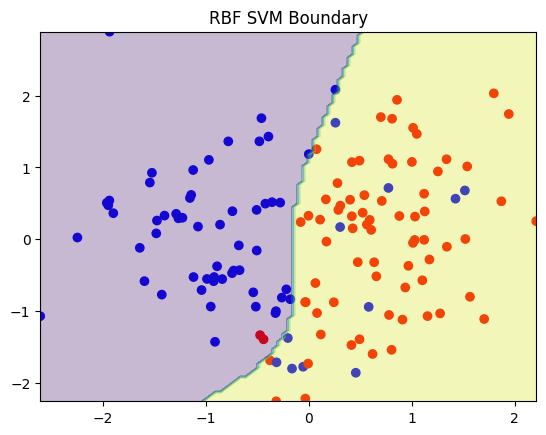

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# -----------------------------
# 1. Dataset 
# -----------------------------
X, y = make_classification(n_samples=200, n_features=2,
                           n_redundant=0, n_informative=2,
                           random_state=42)

# Convert labels to {-1, +1}
y = np.where(y == 0, -1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# 2. SVM FROM SCRATCH
# -----------------------------
class SVM_Scratch:
    def __init__(self, lr=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = lr
        self.lambda_param = lambda_param
        self.n_iters = n_iters

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y[idx] * (np.dot(x_i, self.w) + self.b) >= 1

                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - y[idx] * x_i)
                    self.b -= self.lr * (-y[idx])

    def predict(self, X):
        linear_output = np.dot(X, self.w) + self.b
        return np.sign(linear_output)

# -----------------------------
# Train Scratch Model
# -----------------------------
start = time.time()

svm_scratch = SVM_Scratch()
svm_scratch.fit(X_train, y_train)

scratch_time = time.time() - start

y_pred_train = svm_scratch.predict(X_train)
y_pred_test = svm_scratch.predict(X_test)

print("\n--- Scratch SVM ---")
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("Training Time:", scratch_time)


# -----------------------------
# 3. Library SVM (Linear)
# -----------------------------
start = time.time()

svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

linear_time = time.time() - start

print("\n--- Library SVM (Linear) ---")
print("Train Accuracy:", svm_linear.score(X_train, y_train))
print("Test Accuracy:", svm_linear.score(X_test, y_test))
print("Training Time:", linear_time)


# -----------------------------
# 4. Library SVM (RBF Kernel)
# -----------------------------
start = time.time()

svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

rbf_time = time.time() - start

print("\n--- Library SVM (RBF) ---")
print("Train Accuracy:", svm_rbf.score(X_train, y_train))
print("Test Accuracy:", svm_rbf.score(X_test, y_test))
print("Training Time:", rbf_time)


# -----------------------------
# 5. Decision Boundary Plot
# -----------------------------
def plot_boundary(model, X, y, title):
    plt.figure()
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')

    ax = plt.gca()
    x_vals = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 100)

    if hasattr(model, 'coef_'):  # linear SVM
        w = model.coef_[0]
        b = model.intercept_[0]
        y_vals = -(w[0]*x_vals + b)/w[1]
        plt.plot(x_vals, y_vals)
    else:
        # mesh grid for nonlinear
        xx, yy = np.meshgrid(
            np.linspace(X[:,0].min(), X[:,0].max(), 100),
            np.linspace(X[:,1].min(), X[:,1].max(), 100)
        )
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        plt.contourf(xx, yy, Z, alpha=0.3)

    plt.title(title)
    plt.show()


plot_boundary(svm_linear, X_train, y_train, "Linear SVM Boundary")
plot_boundary(svm_rbf, X_train, y_train, "RBF SVM Boundary")